#**Weather-Driven Traffic Prediction System**

**Authored by:** Phuong Linh Tran (Lily)

**Duration:** 90 mins

**Level:** Intermediate

**Pre-requisite Skills:** Python, Data cleaning, Data analysis, Data visualisation, Time-Series Analysis, Feature Engineering, Optimisation Methods, Deep Learning

### Scenario

Urban traffic congestion is influenced by a range of external factors, among which weather conditions—particularly rainfall—play a significant role. Sudden or heavy rain can reduce visibility, affect road conditions, and lead to slower vehicle movement, increasing the likelihood of congestion during peak travel periods.

In this context, understanding and predicting rainfall patterns becomes a valuable step toward anticipating potential traffic disruptions. Rather than relying solely on real-time observations, predictive models can provide early signals about upcoming weather conditions. These signals can then be further interpreted or communicated through higher-level systems, such as decision-support tools or natural language interfaces.

This project focuses on analysing historical weather data to predict rainfall behaviour and explore how these predictions could be used to support broader applications. In particular, the results may serve as inputs for systems that generate human-readable insights, such as explaining how expected weather conditions could impact traffic flow under different scenarios.

### Introduction

This project aims to analyse weather data and develop machine learning models to predict rainfall based on historical observations. Rainfall is a complex and highly variable phenomenon, influenced by multiple interacting atmospheric factors. As a result, predicting rainfall requires not only careful data preprocessing but also the use of models capable of capturing nonlinear relationships.

The analysis begins with data cleaning and feature engineering, including the extraction of time-based features and transformation of the rainfall target to improve model stability. A range of regression models are then applied and compared to evaluate their ability to learn patterns from the data. Both simple baseline models and more advanced ensemble methods are considered to provide a balanced assessment of model performance.

Beyond prediction accuracy, this project also considers how the modelling results could be used in a broader context. For example, predicted rainfall levels can be interpreted as indicators of potential environmental impact. When combined with additional reasoning mechanisms, such as prompt-based language models, these predictions could support higher-level insights, including explaining how certain weather conditions may influence traffic behaviour.

Overall, the project focuses on building a structured pipeline for rainfall prediction while maintaining flexibility for future extensions, including integration with decision-support or explanatory systems.

#0. Import libraries and authentication

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

#1. Load dataset

In this first step, I load the BOM weather dataset and inspect its basic structure to understand what information is available before any cleaning or transformation. This helps me check the size of the dataset, the column layout, and the overall data quality so I can prepare the next preprocessing steps in a more informed way.

In [3]:
# =========================
# 1. Load dataset
# =========================
df = pd.read_csv("/content/drive/MyDrive/bom-weather-at-olympic-park.csv")

print("Original shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Original shape: (11359, 43)

Columns:
['local_date_time_full', 'refresh_message', 'ID', 'main_ID', 'name', 'state_time_zone', 'time_zone', 'product_name', 'state', 'sort_order', 'wmo', 'history_product', 'local_date_time', 'aifstime_utc', 'lat', 'lon', 'apparent_t', 'cloud', 'cloud_base_m', 'cloud_oktas', 'cloud_type_id', 'cloud_type', 'delta_t', 'gust_kmh', 'gust_kt', 'air_temp', 'dewpt', 'press', 'press_qnh', 'press_msl', 'press_tend', 'rain_trace', 'rel_hum', 'sea_state', 'swell_dir_worded', 'swell_height', 'swell_period', 'vis_km', 'weather', 'wind_dir', 'wind_spd_kmh', 'wind_spd_kt', 'latlong']


The dataset loaded successfully and provides a suitable starting point for the analysis. At this stage, the main purpose is simply to become familiar with the available weather variables and check whether the data appears complete and usable. This initial inspection is important because it sets the direction for the later preprocessing and modelling steps.

#2. Preprocess and basic cleaning

In the preprocessing stage, I clean the raw dataset so it is ready for analysis and modelling. This includes removing duplicates, fixing the datetime format, handling invalid records, and preparing the data in a more structured form. The purpose of this step is to make sure the later results are based on consistent and reliable input data.

In [4]:
# =========================
# 2. Basic cleaning
# =========================

# Remove duplicate rows
duplicate_count = df.duplicated().sum()
df = df.drop_duplicates()
print("\nDuplicates removed:", duplicate_count)
print("Shape after dropping duplicates:", df.shape)

# Convert datetime column
df["local_date_time_full"] = pd.to_datetime(df["local_date_time_full"], errors="coerce")

# Drop rows with invalid datetime
df = df.dropna(subset=["local_date_time_full"])


Duplicates removed: 0
Shape after dropping duplicates: (11359, 43)


The preprocessing results show that the dataset is reasonably clean and suitable for further analysis. Duplicate and invalid records were removed where necessary, and the datetime field was converted into a usable format for time-based feature engineering. This step is important because weather-driven traffic analysis depends heavily on accurate timing, so having a clean and consistent time structure makes the later modelling process much more reliable.

#3. Feature engineering from datetime

In this block, I create new time-based features from the original timestamp, such as hour, day of week, weekend, rush-hour indicators, and cyclic time variables. The aim is to capture patterns that may not be visible in the raw datetime column itself, especially patterns related to traffic timing and daily or seasonal weather cycles.

In [5]:
# =========================
# 3. Feature engineering from datetime
# =========================
df["year_num"] = df["local_date_time_full"].dt.year
df["month_num"] = df["local_date_time_full"].dt.month
df["day_num"] = df["local_date_time_full"].dt.day
df["hour"] = df["local_date_time_full"].dt.hour
df["dayofweek_num"] = df["local_date_time_full"].dt.dayofweek
df["is_weekend"] = df["dayofweek_num"].isin([5, 6]).astype(int)

# Extra time-based features
df["is_rush_hour"] = df["hour"].isin([7, 8, 9, 16, 17, 18]).astype(int)
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["month_sin"] = np.sin(2 * np.pi * df["month_num"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month_num"] / 12)

These engineered time features make the dataset more meaningful for prediction because they describe when each weather observation occurred, not just what the weather was. This is especially useful for a weather-driven traffic project, since the effect of rainfall is likely to depend on timing. For example, rain during rush hour is usually more relevant to congestion than rain late at night, so these features help the model capture that context more clearly.

#4. Define target and feature set

In this step, I define the prediction target and separate it from the input features. The rainfall variable is transformed using a log function to reduce skewness and make the target more stable for modelling. At the same time, irrelevant or non-predictive columns are removed so the models can focus on the features that are more likely to carry useful signal.

In [6]:
# =========================
# 4. Define regression target
# =========================
# Remove rows where the target is missing
df = df.dropna(subset=["rain_trace"]).reset_index(drop=True)
# Target = rainfall amount
y = np.log1p(df["rain_trace"])

print("\nTarget summary:")
print(y.describe())

# =========================
# Drop irrelevant / weak / leakage-prone columns
# =========================
# Remove:
# - raw datetime strings
# - identifiers / metadata
# - constant columns
# - columns with all missing values
drop_cols = [
    "local_date_time_full",
    "local_date_time",
    "refresh_message",
    "ID",
    "main_ID",
    "name",
    "state_time_zone",
    "time_zone",
    "product_name",
    "state",
    "sort_order",
    "wmo",
    "history_product",
    "aifstime_utc",
    "lat",
    "lon",
    "latlong",
    "cloud_type_id",
    "cloud_oktas",
    "cloud_base_m",
    "swell_height",
    "rain_trace"   # target
]

# Drop only columns that actually exist
drop_cols = [col for col in drop_cols if col in df.columns]

X = df.drop(columns=drop_cols)


Target summary:
count    11317.000000
mean         0.246823
std          0.600483
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          3.788725
Name: rain_trace, dtype: float64


The target and feature set are now clearly defined, which is an important step before modelling. Applying the log transformation helps reduce the effect of extreme rainfall values and makes the target distribution easier to learn. Removing unnecessary columns also improves the overall quality of the input data by reducing noise and avoiding information that would not meaningfully support prediction.

#5. Remove constant and high-missing columns

Here, I further refine the feature set by removing columns that do not add useful information, such as constant variables or columns with too many missing values. The purpose of this step is to improve data quality and reduce the risk of weak or unreliable features affecting model performance.

In [7]:
# =========================
# 5. Drop irrelevant / weak / leakage-prone columns
# =========================
# Remove:
# - raw datetime strings
# - identifiers / metadata
# - constant columns
# - columns with all missing values
drop_cols = [
    "local_date_time_full",
    "local_date_time",
    "refresh_message",
    "ID",
    "main_ID",
    "name",
    "state_time_zone",
    "time_zone",
    "product_name",
    "state",
    "sort_order",
    "wmo",
    "history_product",
    "aifstime_utc",
    "lat",
    "lon",
    "latlong",
    "cloud_type_id",
    "cloud_oktas",
    "cloud_base_m",
    "swell_height",
    "rain_trace"   # target
]

# Drop only columns that actually exist
drop_cols = [col for col in drop_cols if col in df.columns]

X = df.drop(columns=drop_cols)

# =========================
# Remove constant columns automatically
# =========================
constant_cols = [col for col in X.columns if X[col].nunique(dropna=False) <= 1]
if constant_cols:
    print("\nConstant columns removed:", constant_cols)
    X = X.drop(columns=constant_cols)

# =========================
# Remove columns with too many missing values
# =========================
missing_ratio = X.isnull().mean().sort_values(ascending=False)
print("\nMissing ratio by column:")
print(missing_ratio[missing_ratio > 0])

high_missing_cols = missing_ratio[missing_ratio > 0.5].index.tolist()

if high_missing_cols:
    print("\nHigh-missing columns removed:", high_missing_cols)
    X = X.drop(columns=high_missing_cols)

print("\nRemaining feature columns:")
print(X.columns.tolist())


Constant columns removed: ['cloud', 'cloud_type', 'press_tend', 'sea_state', 'swell_dir_worded', 'swell_period']

Missing ratio by column:
vis_km       0.002032
press_msl    0.001414
press        0.001414
press_qnh    0.001414
dtype: float64

Remaining feature columns:
['apparent_t', 'delta_t', 'gust_kmh', 'gust_kt', 'air_temp', 'dewpt', 'press', 'press_qnh', 'press_msl', 'rel_hum', 'vis_km', 'weather', 'wind_dir', 'wind_spd_kmh', 'wind_spd_kt', 'year_num', 'month_num', 'day_num', 'hour', 'dayofweek_num', 'is_weekend', 'is_rush_hour', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']


This filtering step makes the dataset cleaner and more practical for modelling. Constant columns provide no predictive value, and columns with very high missingness may weaken the analysis if retained. By removing them at this stage, the final dataset becomes more focused and easier for the model to learn from.

#6. Build preprocessing pipeline

In this block, I prepare a formal preprocessing pipeline for numeric and categorical variables. This includes imputing missing values, scaling numeric data, and encoding categorical variables. The goal is to make sure the features are transformed consistently and appropriately before being passed into the machine learning models.

In [8]:
# =========================
# 6. Separate numeric and categorical features
# =========================
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "bool"]).columns.tolist()

print("\nNumeric features:", numeric_features)
print("Categorical features:", categorical_features)

# =========================
# Preprocessing pipelines
# =========================
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])


Numeric features: ['apparent_t', 'delta_t', 'gust_kmh', 'gust_kt', 'air_temp', 'dewpt', 'press', 'press_qnh', 'press_msl', 'rel_hum', 'vis_km', 'wind_spd_kmh', 'wind_spd_kt', 'is_weekend', 'is_rush_hour', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']
Categorical features: ['weather', 'wind_dir']


The preprocessing pipeline provides a structured and reusable way to prepare the data for modelling. Numeric and categorical features are handled separately so that each type receives the most suitable treatment. This improves both the quality of the input data and the reliability of the later model comparisons.

#7. Time-based train-test split

In this step, I split the dataset into training and testing sets based on time order rather than random sampling. The purpose is to keep the workflow realistic, since weather data is naturally sequential and the model should learn from past observations to predict future ones.

In [9]:
# =========================
# 7. Time-based train-test split
# =========================
# Sort data by time before splitting
df = df.sort_values("local_date_time_full").reset_index(drop=True)

# Recreate target after sorting
y = np.log1p(df["rain_trace"])

# Recreate feature set after sorting
X = df.drop(columns=drop_cols)

# Remove constant columns again after sorting
constant_cols = [col for col in X.columns if X[col].nunique(dropna=False) <= 1]
if constant_cols:
    X = X.drop(columns=constant_cols)

# Remove high-missing columns again after sorting
missing_ratio = X.isnull().mean()
high_missing_cols = missing_ratio[missing_ratio > 0.5].index.tolist()
if high_missing_cols:
    X = X.drop(columns=high_missing_cols)

# Rebuild numeric and categorical feature lists
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "bool"]).columns.tolist()

# Rebuild preprocessor after updated feature lists
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# Time-based split
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)

# =========================
# Fit and transform
# =========================
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("\nPreprocessing completed.")
print("Processed train shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)


Train shape: (9053, 26)
Test shape: (2264, 26)

Preprocessing completed.
Processed train shape: (9053, 41)
Processed test shape: (2264, 41)


Using a time-based split makes the evaluation more realistic and avoids leakage from future observations into the training data. This is especially important in a forecasting-style problem like this one, where the real goal is to learn from earlier weather patterns and test the model on later periods. It also makes the results more credible for later traffic-related interpretation.

#8. Target distribution / histogram

Before training any models, I examine the distribution of the target variable to better understand its shape and behaviour. This helps me see whether rainfall is balanced or highly skewed, and whether any transformation is needed to make the modelling task more stable.

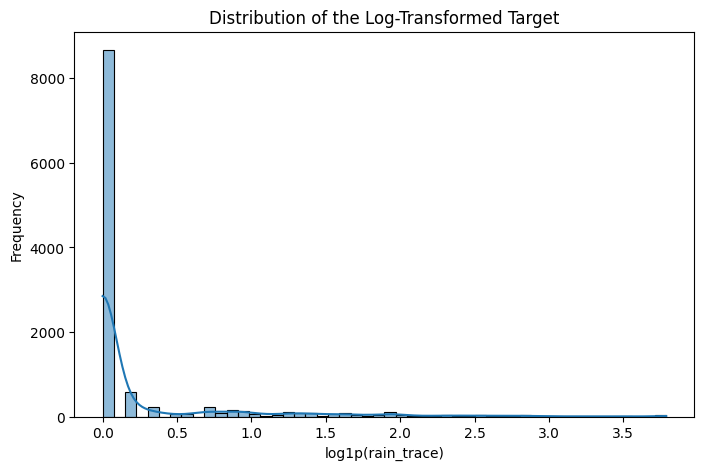

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(y, bins=50, kde=True)
plt.title("Distribution of the Log-Transformed Target")
plt.xlabel("log1p(rain_trace)")
plt.ylabel("Frequency")
plt.show()

The target distribution shows that most observations are concentrated around low rainfall values, while heavier rainfall occurs much less often. This is a common pattern in weather data and helps explain why the rainfall target is difficult to predict. It also supports the use of a log transformation, since that makes the target less dominated by extreme values.

#9. Boxplot of target

In this block, I use a boxplot to get a quick view of the spread of the rainfall target and to check whether there are potential extreme values. The purpose is to understand how concentrated or dispersed the target is before modelling.

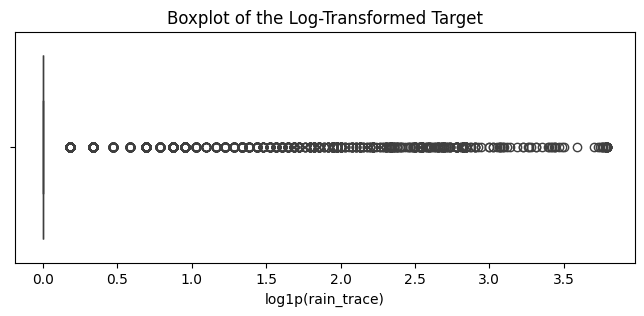

In [11]:
plt.figure(figsize=(8,3))
sns.boxplot(x=y)
plt.title("Boxplot of the Log-Transformed Target")
plt.xlabel("log1p(rain_trace)")
plt.show()

The boxplot confirms that the target is heavily concentrated at the lower end, with a smaller number of higher rainfall observations extending beyond the main range. These are likely to reflect real weather events rather than simple data errors. For this reason, they are not removed, but instead handled more carefully through transformation and suitable model choice.

#10. Distribution after log transformation

Here, I visualise the target again after applying the log transformation. The aim is to check whether the transformation makes the rainfall distribution more balanced and easier to model.

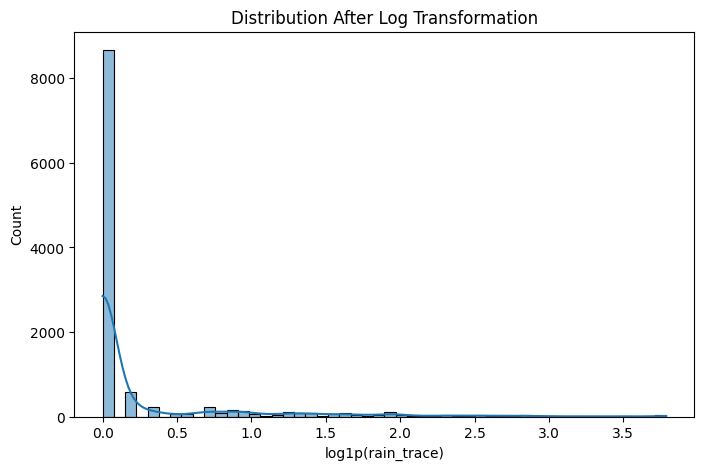

In [12]:
import numpy as np

plt.figure(figsize=(8,5))
sns.histplot(y, bins=50, kde=True)
plt.title("Distribution After Log Transformation")
plt.xlabel("log1p(rain_trace)")
plt.show()

The transformed target distribution is easier to work with than the original rainfall scale because it reduces the influence of very large rainfall values. This does not remove important weather events, but it makes the target less dominated by a few extreme observations.

For this project, that is useful because the model is not only trying to understand whether rain occurred, but also how rainfall intensity changes over time. If the target remains too skewed, the model may focus too heavily on rare heavy-rain cases and perform poorly on the more common light-rain or no-rain periods. By applying the log transformation, the learning problem becomes more balanced.

This also supports later traffic analysis. In a weather-driven congestion framework, it is often not necessary to treat a 40 mm rainfall event as forty times more influential than a 1 mm event in raw mathematical terms. What matters more is learning the general relationship between weather intensity and likely traffic conditions in a stable and interpretable way.

#11. Distribution of main weather features

In this step, I explore the main weather variables using histograms to see how their values are distributed across the dataset. This gives a clearer picture of which variables are relatively stable and which appear more uneven or event-driven.

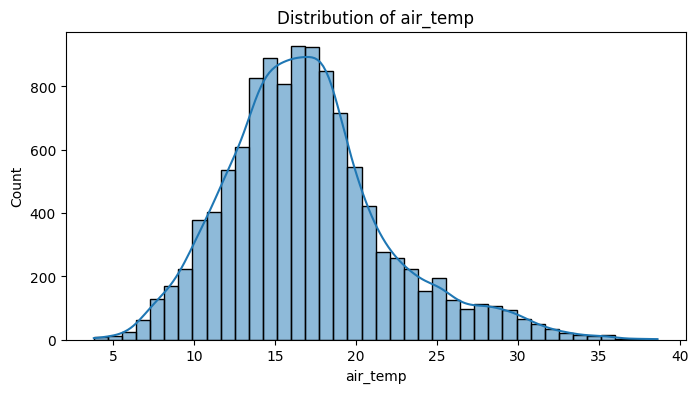

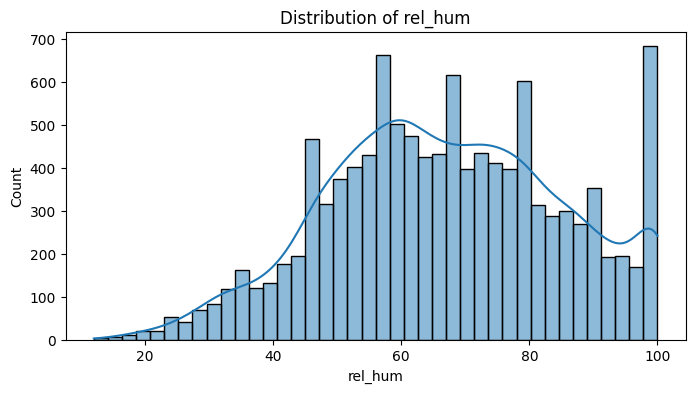

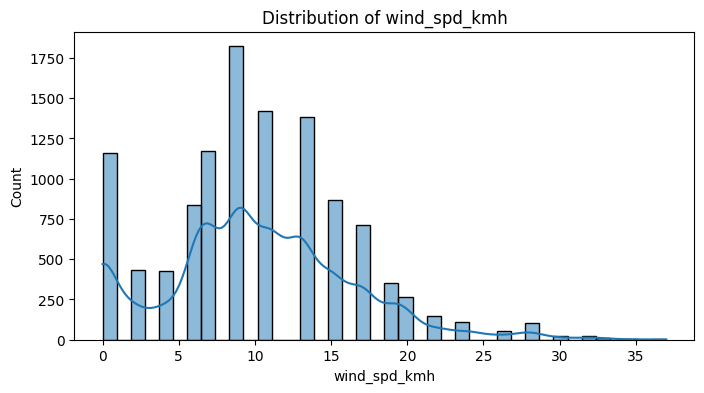

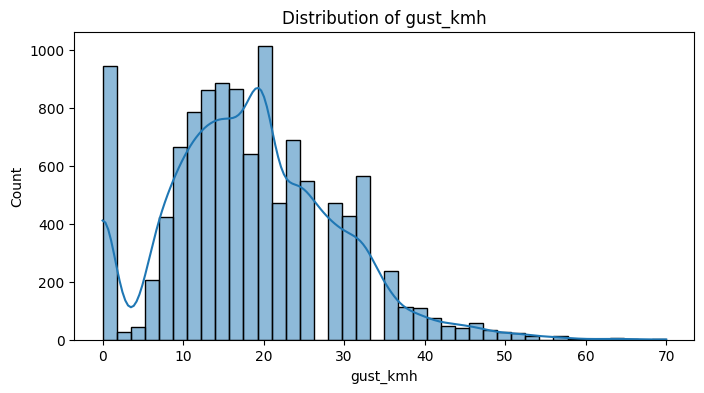

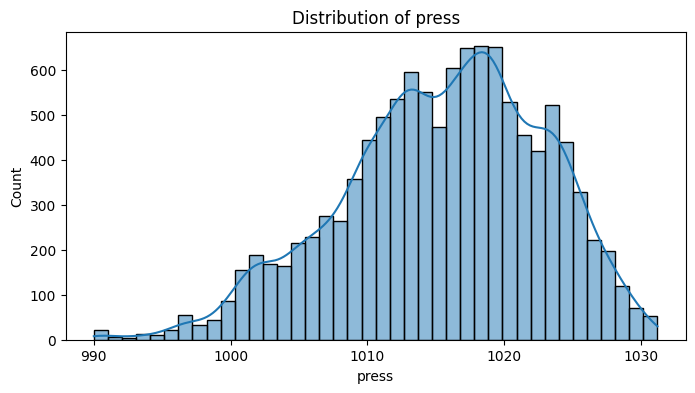

In [13]:
features = ["air_temp", "rel_hum", "wind_spd_kmh", "gust_kmh", "press"]

for col in features:
    if col in df.columns:
        plt.figure(figsize=(8,4))
        sns.histplot(df[col], bins=40, kde=True)
        plt.title(f"Distribution of {col}")
        plt.show()

The histograms of the main weather variables give a useful first impression of how conditions are distributed across the dataset. Some variables, such as air temperature and pressure, are likely to appear more concentrated around a central range, which suggests relatively stable environmental conditions over the observation period. Others, such as wind speed and gust speed, may show more spread or skewness, reflecting the more irregular nature of short-term weather changes.

Relative humidity is especially interesting in this project because it often increases during wetter conditions and may act as an indirect signal for rainfall risk. Wind and gust variables can also matter, not only for rainfall formation but for traffic safety. Strong gusts combined with wet roads may increase driving difficulty, especially for exposed roads or larger vehicles.

These feature distributions help us understand that the weather variables do not all behave in the same way. Some are stable background conditions, while others are more event-driven. This matters for a traffic-focused prediction problem because congestion is usually influenced by a combination of slow-changing atmospheric conditions and sudden disruptive events.

#12. Scatter plots between features and rainfall

In this block, I plot selected weather variables against rainfall to see whether any simple relationships can be observed. The goal is not to prove a direct relationship from one chart alone, but to get an early sense of how the variables may interact with the target.

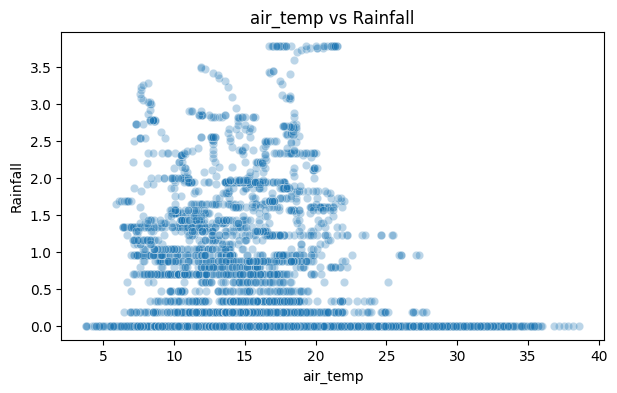

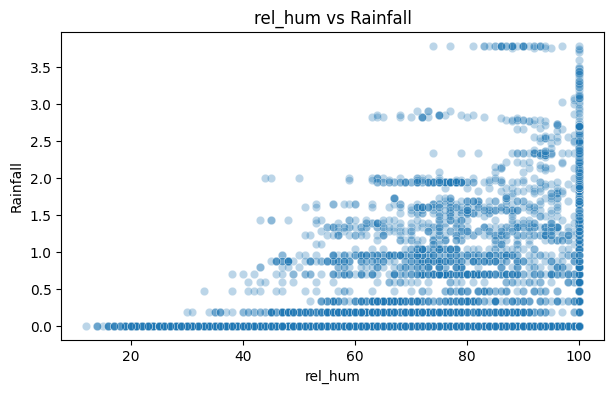

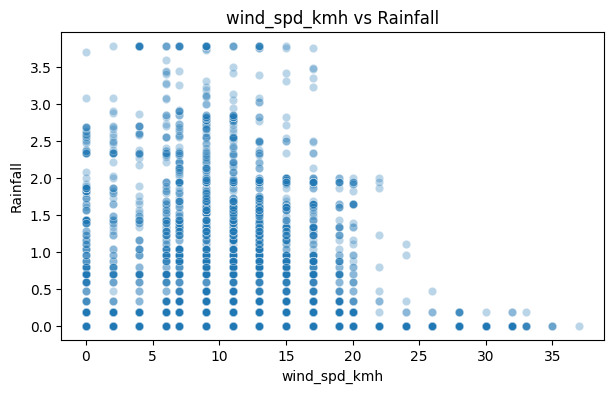

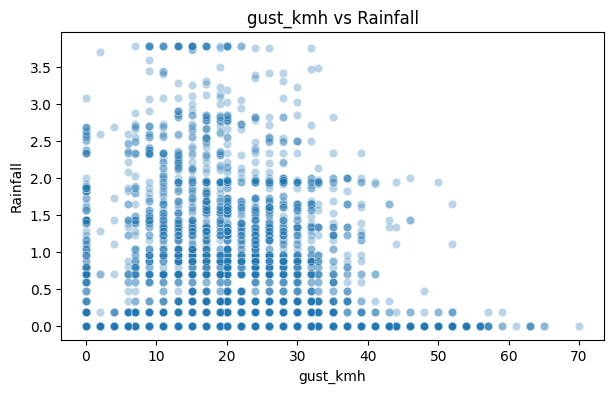

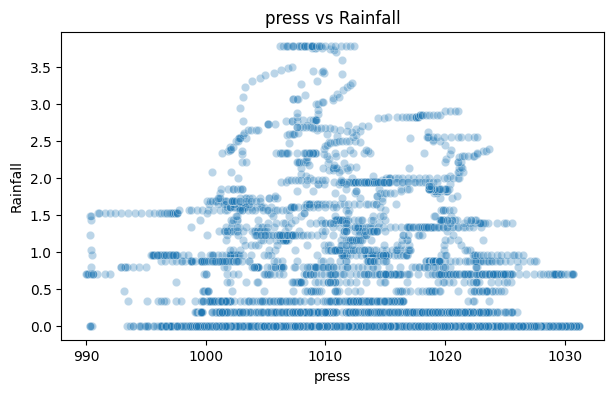

In [14]:
for col in ["air_temp", "rel_hum", "wind_spd_kmh", "gust_kmh", "press"]:
    if col in df.columns:
        plt.figure(figsize=(7,4))
        sns.scatterplot(x=df[col], y=y, alpha=0.3)
        plt.title(f"{col} vs Rainfall")
        plt.xlabel(col)
        plt.ylabel("Rainfall")
        plt.show()

The scatter plots show that the relationship between individual weather variables and rainfall is not perfectly linear. This is expected, because rainfall is a complex meteorological outcome that depends on multiple conditions interacting at the same time rather than on a single feature acting alone.

Even so, some broad tendencies can still be explored. Higher relative humidity is likely to appear more often alongside rainfall, which is reasonable because moist air supports cloud formation and precipitation. Pressure may show a weak negative relationship with rainfall, since lower-pressure systems are often associated with unstable weather conditions. Wind speed and gust speed may not show a strong direct pattern on their own, but they could still become useful when combined with other features.

From a traffic congestion point of view, this is an important finding. It suggests that no single weather feature will be enough to explain congestion risk. Instead, the effect of weather on traffic is likely to emerge from combinations of factors, such as moderate-to-high rainfall during peak commuting periods, or humid and unstable conditions that coincide with busy travel windows. This supports the decision to keep multiple engineered time and weather features in the model rather than relying on simple one-variable relationships.

#13. Correlation heatmap

Here, I use a correlation heatmap to get a broader view of how the numeric variables relate to one another. The purpose is to identify any clear associations, overlapping information, or early signs of useful predictive patterns.

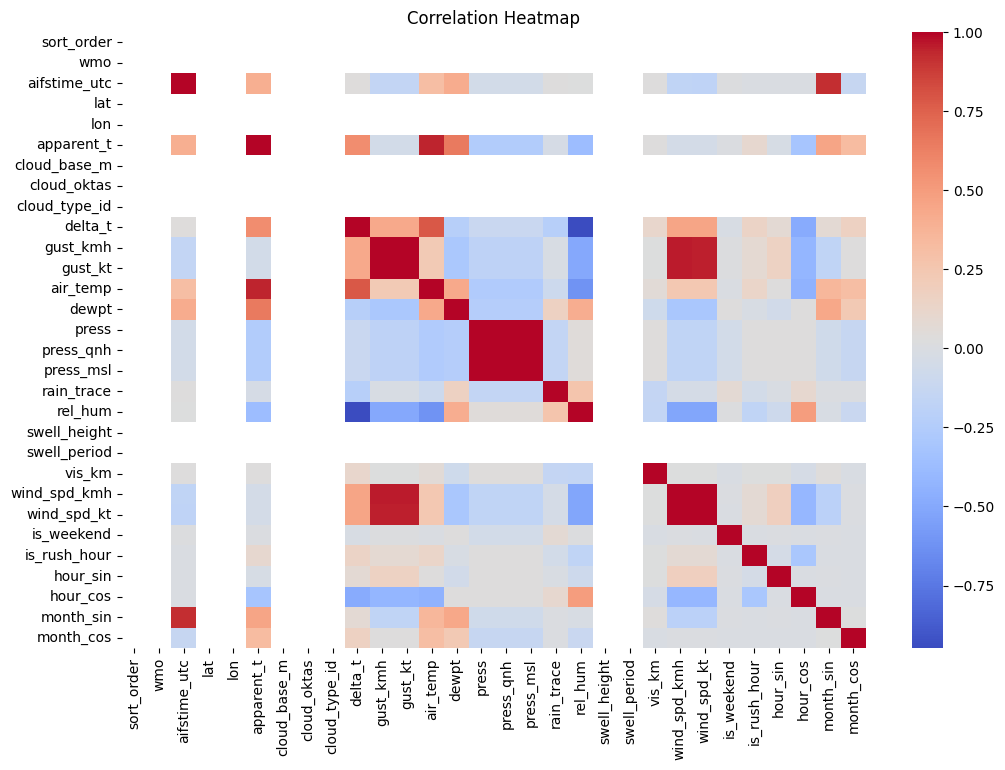

In [15]:
numeric_cols = [col for col in df.columns if df[col].dtype in ["int64", "float64"]]

plt.figure(figsize=(12,8))
sns.heatmap(df[numeric_cols].corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap provides a broader view of how the numeric variables move together. It is useful for identifying pairs of features that may carry similar information, as well as for checking whether rainfall has any obvious direct association with the main weather indicators.

In this dataset, the correlations with rainfall appear to be present but not especially strong. That result is actually quite realistic. Rainfall often depends on a combination of atmospheric conditions rather than a single dominant variable, so weak-to-moderate pairwise correlations are common. This means the model may need to rely on multivariable interactions instead of expecting one weather measurement to explain rainfall on its own.

For the traffic congestion context, this is a helpful reminder that the final relationship between weather and congestion is likely to be layered. Rainfall may not simply rise or fall with one weather feature in a clean straight line. Instead, it may emerge from a particular combination of humidity, pressure, wind, and time-related factors. The heatmap therefore supports the use of a machine learning pipeline rather than a very simple rule-based approach.

#14. Hourly rainfall pattern

In this step, I examine how rainfall changes across different hours of the day. The aim is to see whether there is any timing pattern that may later be relevant to traffic congestion, especially during peak travel periods.

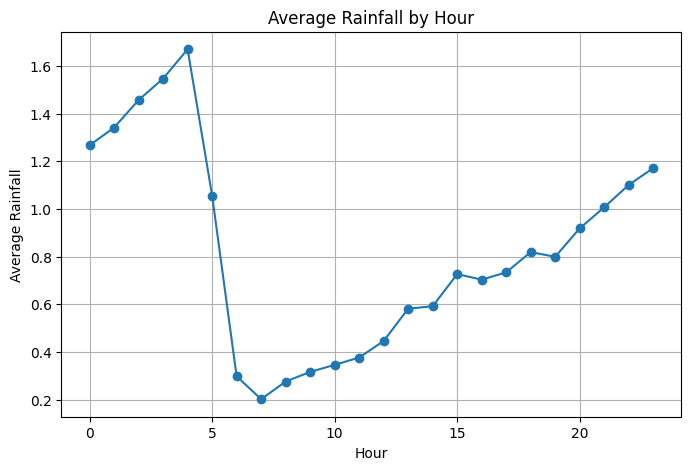

In [16]:
rain_by_hour = df.groupby("hour")["rain_trace"].mean()

plt.figure(figsize=(8,5))
rain_by_hour.plot(marker="o")
plt.title("Average Rainfall by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Rainfall")
plt.grid()
plt.show()

The hourly average rainfall pattern suggests that rainfall is not evenly distributed across the day. In this dataset, rainfall appears to be higher during late-night and early-morning hours, while lower average values are observed through much of the daytime. This may reflect the local weather cycle during the recorded period, where rainfall events are more likely to build overnight or persist into the early morning.

This finding is interesting when linked to traffic congestion. At first glance, heavier rainfall outside major commuting hours may seem less important. However, rain that occurs in the early morning can still affect the morning peak if wet road conditions, reduced visibility, or residual water remain when traffic starts to increase. Even moderate rainfall during rush hour may create more disruption than heavier rainfall at a quiet hour because congestion depends not only on weather severity but also on how many vehicles are already on the network.

That is exactly why the added time-based features, especially 'hour', 'is_rush_hour', and the cyclic encoding of hour, are valuable in this project. They allow the later model to capture not just whether rainfall occurred, but when it occurred. This timing dimension is essential in a weather-driven traffic congestion system because the impact of rain is highly context-dependent.

#15. Model training and initial comparison

After preprocessing and initial exploration, the next step is to train a set of regression models to predict rainfall from weather-related features. The target variable has been log-transformed using 'log1p(rain_trace)' to stabilise its distribution, while predictions will later be converted back to the original scale for easier interpretation.

Based on these considerations, a diverse set of models is selected to compare performance across different levels of complexity and modelling approaches:

- **Dummy Regressor**: used as a baseline model to represent the minimum performance level. It does not learn patterns but helps confirm whether other models are meaningful.

- **Linear Regression**: included as a simple and interpretable model to check whether rainfall can be explained through general linear relationships.

- **Ridge Regression**: used as a regularised version of linear regression to improve stability and reduce overfitting when many features are present.

- **KNN Regressor**: included to explore instance-based learning, where predictions are based on similarity between observations rather than a global model.

- **Random Forest Regressor**: chosen because it can capture nonlinear relationships and interactions between multiple weather variables.

- **Extra Trees Regressor**: similar to Random Forest but introduces more randomness, which can improve generalisation and reduce variance.

- **Gradient Boosting Regressor**: included to model complex patterns by sequentially correcting prediction errors, often leading to strong performance.

- **HistGradientBoosting Regressor**: a more efficient version of gradient boosting that works well on larger datasets and can improve training speed and accuracy.

- **XGBoost Regressor**: included as an advanced boosting method known for its strong performance and ability to handle complex feature interactions.

- **AdaBoost Regressor**: used to test another boosting approach that focuses on improving weak learners by reweighting difficult observations.

The models are evaluated using MAE, RMSE, and R². MAE reflects average prediction error, RMSE places more emphasis on larger errors such as missed heavy rainfall, and R² shows how much variation in rainfall is explained. Since the models are trained on the log-transformed target, predictions are converted back using 'expm1()' before evaluation to keep the results interpretable in the original rainfall scale.

In [17]:
# =========================
# 15. Extended model training and evaluation
# =========================

import pandas as pd
import numpy as np
import warnings

from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    median_absolute_error,
    explained_variance_score,
    accuracy_score
)

warnings.filterwarnings("ignore")

# Optional XGBoost
xgb_available = False
try:
    from xgboost import XGBRegressor
    xgb_available = True
except ImportError:
    print("XGBoost is not installed. Skipping XGBRegressor.")

# Candidate models
models = {
    "Dummy Regressor": DummyRegressor(strategy="mean"),
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=7, weights="distance"),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),
    "Extra Trees": ExtraTreesRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),
    "AdaBoost": AdaBoostRegressor(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=200,
        learning_rate=0.05,
        max_depth=6,
        random_state=42
    )
}

if xgb_available:
    models["XGBoost"] = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

results = []
trained_models = {}

# Convert test target back to original rainfall scale
y_test_original = np.expm1(y_test)

# Define a small threshold for rain event detection
# You can change 0.1 to 0.2 or 0.5 depending on your interpretation of a meaningful rain event.
rain_threshold = 0.1

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Train on log-transformed target
    pipeline.fit(X_train, y_train)

    # Predict on log scale
    y_pred_log = pipeline.predict(X_test)

    # Convert back to original rainfall scale
    y_pred_original = np.expm1(y_pred_log)
    y_pred_original = np.clip(y_pred_original, 0, None)

    # Regression metrics
    mae = mean_absolute_error(y_test_original, y_pred_original)
    mse = mean_squared_error(y_test_original, y_pred_original)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_original, y_pred_original)
    medae = median_absolute_error(y_test_original, y_pred_original)
    evs = explained_variance_score(y_test_original, y_pred_original)

    # MAPE with protection against division by zero
    nonzero_mask = y_test_original > 0
    if nonzero_mask.sum() > 0:
        mape = np.mean(
            np.abs((y_test_original[nonzero_mask] - y_pred_original[nonzero_mask]) / y_test_original[nonzero_mask])
        ) * 100
    else:
        mape = np.nan

    # Supplementary rain / no-rain accuracy
    y_test_event = (y_test_original >= rain_threshold).astype(int)
    y_pred_event = (y_pred_original >= rain_threshold).astype(int)
    event_accuracy = accuracy_score(y_test_event, y_pred_event)

    results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "MedianAE": medae,
        "R2": r2,
        "ExplainedVariance": evs,
        "MAPE_nonzero_%": mape,
        "RainEventAccuracy": event_accuracy
    })

    trained_models[name] = pipeline

results_df = pd.DataFrame(results).sort_values(by="RMSE").reset_index(drop=True)

print("Extended model comparison results:")
display(results_df)

Extended model comparison results:


,Model,MAE,MSE,RMSE,MedianAE,R2,ExplainedVariance,MAPE_nonzero_%,RainEventAccuracy
0,Gradient Boosting,0.677597,5.113476,2.261300,0.014146,0.194708,2.231142e-01,81.692801,0.796378
1,XGBoost,0.680081,5.189327,2.278010,0.006745,0.182762,2.122291e-01,84.019131,0.834364
2,Extra Trees,0.716813,5.223843,2.285573,0.059975,0.177327,2.025060e-01,81.191399,0.761042
3,HistGradientBoosting,0.683604,5.257374,2.292896,0.010694,0.172046,2.036899e-01,86.420435,0.847615
4,Random Forest,0.693909,5.268132,2.295241,0.025166,0.170352,1.970414e-01,81.750632,0.835689
5,Ridge Regression,0.751934,5.648989,2.376760,0.063687,0.110373,1.412293e-01,82.017540,0.705830
6,Linear Regression,0.739152,5.675380,2.382306,0.031049,0.106217,1.401019e-01,80.663854,0.736749
7,AdaBoost,0.948832,6.135501,2.476994,0.204212,0.033755,4.373910e-02,107.433738,0.536661
8,Dummy Regressor,0.926596,6.580038,2.565159,0.280987,-0.036253,-2.220446e-16,71.349756,0.220848
9,KNN Regressor,0.802297,7.261781,2.694769,0.000000,-0.143616,-1.015099e-01,111.877695,0.806537


The extended model comparison shows a clear improvement over the earlier baseline models, especially when using ensemble-based approaches.

- Gradient Boosting Regressor achieved the best performance overall, with the lowest RMSE and highest R². This suggests it is currently the most effective model for capturing rainfall patterns in this dataset.

- Other ensemble models such as XGBoost, Extra Trees, HistGradientBoosting, and Random Forest also performed consistently well, with similar error levels. This indicates that rainfall prediction benefits from nonlinear models that can capture interactions between weather variables and time-based features.

- In general, boosting models (Gradient Boosting, XGBoost) perform slightly better than bagging models (Random Forest, Extra Trees), which aligns with expectations since boosting is more effective at learning complex patterns.

Although the best R² value is still relatively low (around 0.19), this is reasonable for a rainfall prediction task. Rainfall is inherently difficult to predict because it depends on complex atmospheric processes and factors not fully captured in the dataset.

From a traffic congestion perspective, these results are still useful. Even moderate prediction accuracy can provide meaningful signals, especially when focusing on when rain occurs rather than predicting exact rainfall amounts. This also suggests that further improvements may depend more on feature engineering and model tuning rather than simply changing the model type.

#16. Feature engineering improvement

In this block, I improve the feature set by adding lag variables, rolling statistics, interaction terms, and simple weather-state indicators. The aim is to give the models more useful information about short-term weather history and combined atmospheric conditions, which are likely to matter for rainfall prediction.

In [18]:
# =========================
# BLOCK 1: Advanced feature engineering + rebuild preprocessing
# =========================

import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# -------------------------------------------------
# 1. Start from a clean copy of the dataframe
# -------------------------------------------------
df_fe = df.copy()

# Make sure data is sorted by time
df_fe = df_fe.sort_values("local_date_time_full").reset_index(drop=True)

# Drop rows where target is missing
df_fe = df_fe.dropna(subset=["rain_trace"]).reset_index(drop=True)

# -------------------------------------------------
# 2. Detect commonly used weather columns safely
# -------------------------------------------------
def find_first_existing(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None

humidity_col = find_first_existing(df_fe, ["relative_humidity", "humidity"])
temp_col = find_first_existing(df_fe, ["air_temp", "temperature", "temp"])
wind_col = find_first_existing(df_fe, ["wind_speed_kmh", "wind_spd_kmh", "wind_speed"])
gust_col = find_first_existing(df_fe, ["gust_speed_kmh", "wind_gust_kmh", "gust_kmh"])
pressure_col = find_first_existing(df_fe, ["pressure", "msl_pressure", "station_pressure"])

print("Detected columns:")
print("Humidity:", humidity_col)
print("Temperature:", temp_col)
print("Wind:", wind_col)
print("Gust:", gust_col)
print("Pressure:", pressure_col)

# -------------------------------------------------
# 3. Add lag features
# -------------------------------------------------
# These features help the model capture temporal dependence.
# Only past values are used, so they remain valid in a forecasting setting.

lag_steps = [1, 3, 6]

for lag in lag_steps:
    df_fe[f"rain_lag_{lag}"] = df_fe["rain_trace"].shift(lag)

if humidity_col:
    for lag in lag_steps:
        df_fe[f"{humidity_col}_lag_{lag}"] = df_fe[humidity_col].shift(lag)

if wind_col:
    for lag in lag_steps:
        df_fe[f"{wind_col}_lag_{lag}"] = df_fe[wind_col].shift(lag)

if pressure_col:
    for lag in lag_steps:
        df_fe[f"{pressure_col}_lag_{lag}"] = df_fe[pressure_col].shift(lag)

# -------------------------------------------------
# 4. Add rolling statistics
# -------------------------------------------------
# Rolling features help capture short-term trends and local weather dynamics.

rolling_windows = [3, 6]

for window in rolling_windows:
    df_fe[f"rain_roll_mean_{window}"] = df_fe["rain_trace"].rolling(window).mean()
    df_fe[f"rain_roll_max_{window}"] = df_fe["rain_trace"].rolling(window).max()

if humidity_col:
    for window in rolling_windows:
        df_fe[f"{humidity_col}_roll_mean_{window}"] = df_fe[humidity_col].rolling(window).mean()

if wind_col:
    for window in rolling_windows:
        df_fe[f"{wind_col}_roll_mean_{window}"] = df_fe[wind_col].rolling(window).mean()

if pressure_col:
    for window in rolling_windows:
        df_fe[f"{pressure_col}_roll_mean_{window}"] = df_fe[pressure_col].rolling(window).mean()

# -------------------------------------------------
# 5. Add interaction features
# -------------------------------------------------
# These features help capture combinations of atmospheric conditions.

if temp_col and humidity_col:
    df_fe["temp_x_humidity"] = df_fe[temp_col] * df_fe[humidity_col]

if wind_col and pressure_col:
    df_fe["wind_x_pressure"] = df_fe[wind_col] * df_fe[pressure_col]

if temp_col and pressure_col:
    df_fe["temp_x_pressure"] = df_fe[temp_col] * df_fe[pressure_col]

if humidity_col and pressure_col:
    df_fe["humidity_x_pressure"] = df_fe[humidity_col] * df_fe[pressure_col]

if gust_col and wind_col:
    df_fe["gust_minus_wind"] = df_fe[gust_col] - df_fe[wind_col]

# -------------------------------------------------
# 6. Add event-style weather indicators
# -------------------------------------------------
# These binary features are simple but often useful for tree-based models.

if humidity_col:
    df_fe["high_humidity_flag"] = (df_fe[humidity_col] >= 80).astype(int)

if wind_col:
    df_fe["strong_wind_flag"] = (df_fe[wind_col] >= 20).astype(int)

df_fe["recent_rain_flag"] = (
    df_fe[[col for col in df_fe.columns if col.startswith("rain_lag_")]].max(axis=1) > 0.1
).astype(int)

# -------------------------------------------------
# 7. Drop rows introduced as missing by lag/rolling only
# -------------------------------------------------
# Only remove rows that are missing in the newly created lag/rolling features.
# Keep other missing values for later imputation in the preprocessing pipeline.

new_temporal_cols = [col for col in df_fe.columns if (
    "_lag_" in col or
    "_roll_mean_" in col or
    "_roll_max_" in col
)]

rows_before = len(df_fe)
df_fe = df_fe.dropna(subset=new_temporal_cols).reset_index(drop=True)
rows_after = len(df_fe)

print(f"Rows before lag/rolling cleanup: {rows_before}")
print(f"Rows after lag/rolling cleanup:  {rows_after}")
print(f"Rows removed due to lag/rolling NA: {rows_before - rows_after}")

# -------------------------------------------------
# 8. Rebuild target and feature set
# -------------------------------------------------
# Keep the same modelling choice: log-transform the rainfall target.
y_fe = np.log1p(df_fe["rain_trace"])

# Reuse the original drop list if it already exists
# and make sure rain_trace is removed from the feature matrix.
drop_cols_fe = [
    "rain_trace"
]

# If you already defined drop_cols earlier, reuse them.
if "drop_cols" in globals():
    drop_cols_fe = list(set(drop_cols + ["rain_trace"]))
else:
    # Minimal fallback if drop_cols does not exist
    extra_drop = [
        "local_date_time_full",
        "local_date_time",
        "refresh_message",
        "ID",
        "main_ID",
        "name",
        "state_time_zone",
        "time_zone",
        "product_name",
        "state",
        "sort_order",
        "wmo",
        "history_product",
        "aifstime_utc",
        "lat",
        "lon",
        "latlong",
        "cloud_type_id",
        "cloud_oktas",
        "cloud_base_m",
        "swell_height"
    ]
    drop_cols_fe = [c for c in extra_drop if c in df_fe.columns] + ["rain_trace"]

X_fe = df_fe.drop(columns=[c for c in drop_cols_fe if c in df_fe.columns])

# Remove constant columns again
constant_cols_fe = [col for col in X_fe.columns if X_fe[col].nunique(dropna=False) <= 1]
if constant_cols_fe:
    print("\nConstant columns removed after feature engineering:")
    print(constant_cols_fe)
    X_fe = X_fe.drop(columns=constant_cols_fe)

# Remove high-missing columns again if any remain
missing_ratio_fe = X_fe.isnull().mean().sort_values(ascending=False)
high_missing_cols_fe = missing_ratio_fe[missing_ratio_fe > 0.5].index.tolist()
if high_missing_cols_fe:
    print("\nHigh-missing columns removed after feature engineering:")
    print(high_missing_cols_fe)
    X_fe = X_fe.drop(columns=high_missing_cols_fe)

# -------------------------------------------------
# 9. Separate feature types
# -------------------------------------------------
numeric_features_fe = X_fe.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features_fe = X_fe.select_dtypes(include=["object", "bool"]).columns.tolist()

print("\nNumber of numeric features:", len(numeric_features_fe))
print("Number of categorical features:", len(categorical_features_fe))
print("Total number of features:", X_fe.shape[1])

# -------------------------------------------------
# 10. Rebuild preprocessing pipeline
# -------------------------------------------------
numeric_transformer_fe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_fe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_fe = ColumnTransformer(transformers=[
    ("num", numeric_transformer_fe, numeric_features_fe),
    ("cat", categorical_transformer_fe, categorical_features_fe)
])

# -------------------------------------------------
# 11. Time-based train-test split
# -------------------------------------------------
print("\nFinal engineered dataset shape:", X_fe.shape)

if len(X_fe) == 0:
    raise ValueError("Feature-engineered dataset is empty. Please check lag/rolling cleanup.")

split_index_fe = int(len(X_fe) * 0.8)

X_train_fe = X_fe.iloc[:split_index_fe]
X_test_fe = X_fe.iloc[split_index_fe:]
y_train_fe = y_fe.iloc[:split_index_fe]
y_test_fe = y_fe.iloc[split_index_fe:]

print("Training rows:", len(X_train_fe))
print("Testing rows:", len(X_test_fe))

if len(X_train_fe) < 10:
    raise ValueError("Training set is too small after feature engineering. Reduce lag/rolling complexity.")

print("\nTrain shape:", X_train_fe.shape)
print("Test shape:", X_test_fe.shape)

# Optional quick preview
display(X_train_fe.head())

Detected columns:
Humidity: None
Temperature: air_temp
Wind: wind_spd_kmh
Gust: gust_kmh
Pressure: None
Rows before lag/rolling cleanup: 11317
Rows after lag/rolling cleanup:  11311
Rows removed due to lag/rolling NA: 6

Constant columns removed after feature engineering:
['cloud', 'cloud_type', 'press_tend', 'sea_state', 'swell_dir_worded', 'swell_period']

Number of numeric features: 34
Number of categorical features: 2
Total number of features: 41

Final engineered dataset shape: (11311, 41)
Training rows: 9048
Testing rows: 2263

Train shape: (9048, 41)
Test shape: (2263, 41)


,apparent_t,delta_t,gust_kmh,gust_kt,air_temp,dewpt,press,press_qnh,press_msl,rel_hum,...,wind_spd_kmh_lag_6,rain_roll_mean_3,rain_roll_max_3,rain_roll_mean_6,rain_roll_max_6,wind_spd_kmh_roll_mean_3,wind_spd_kmh_roll_mean_6,gust_minus_wind,strong_wind_flag,recent_rain_flag
0,13.2,5.0,17,9,15.9,5.5,1007.1,1007.1,1007.1,50,...,9.0,0.0,0.0,0.0,0.0,7.333333,6.833333,8,0,0
1,11.8,3.8,13,7,14.3,6.4,1006.5,1006.5,1006.5,59,...,6.0,0.0,0.0,0.0,0.0,8.333333,7.333333,4,0,0
2,12.4,3.3,9,5,14.1,7.4,1006.3,1006.3,1006.3,64,...,9.0,0.0,0.0,0.0,0.0,8.000000,6.833333,3,0,0
3,11.8,3.1,9,5,13.6,7.2,1006.2,1006.2,1006.2,65,...,4.0,0.0,0.0,0.0,0.0,7.000000,7.166667,3,0,0
4,11.7,4.4,15,8,14.0,4.6,1006.2,1006.2,1006.2,53,...,6.0,0.0,0.0,0.0,0.0,6.000000,7.166667,9,0,0


The new engineered features make the dataset more informative by capturing temporal dependence and short-term weather dynamics. This is important because rainfall is rarely an isolated event; it is usually linked to what happened in the previous few hours as well as to combinations of humidity, pressure, temperature, and wind conditions. These added features provide a stronger foundation for the next round of model tuning.

#17. Model tuning for top 5 models

After identifying the strongest candidate models, I tune the top five using time-aware cross-validation. The purpose of this step is to improve performance by finding better model settings while still respecting the chronological nature of the dataset.

In [19]:
# =========================
# BLOCK 2: Model tuning for top 5 models
# =========================

import numpy as np
import pandas as pd
import warnings

from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import (
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor
)

warnings.filterwarnings("ignore")

# Try XGBoost if installed
xgb_available = False
try:
    from xgboost import XGBRegressor
    xgb_available = True
except ImportError:
    print("XGBoost is not installed. XGBoost tuning will be skipped.")

# -------------------------------------------------
# 1. Define time-aware cross-validation
# -------------------------------------------------
tscv = TimeSeriesSplit(n_splits=3)

# -------------------------------------------------
# 2. Build model configs
# -------------------------------------------------
model_configs = {
    "Gradient Boosting": {
        "model": GradientBoostingRegressor(random_state=42),
        "params": {
            "model__n_estimators": [100, 200, 300, 400],
            "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
            "model__max_depth": [2, 3, 4, 5],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4],
            "model__subsample": [0.7, 0.8, 0.9, 1.0]
        }
    },
    "Extra Trees": {
        "model": ExtraTreesRegressor(random_state=42, n_jobs=-1),
        "params": {
            "model__n_estimators": [200, 300, 400, 500],
            "model__max_depth": [None, 10, 20, 30],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4],
            "model__max_features": ["sqrt", "log2", None]
        }
    },
    "HistGradientBoosting": {
        "model": HistGradientBoostingRegressor(random_state=42),
        "params": {
            "model__max_iter": [100, 200, 300, 400],
            "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
            "model__max_depth": [None, 4, 6, 8],
            "model__min_samples_leaf": [10, 20, 30],
            "model__l2_regularization": [0.0, 0.01, 0.1, 1.0]
        }
    },
    "Random Forest": {
        "model": RandomForestRegressor(random_state=42, n_jobs=-1),
        "params": {
            "model__n_estimators": [200, 300, 400, 500],
            "model__max_depth": [None, 10, 20, 30],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4],
            "model__max_features": ["sqrt", "log2", None]
        }
    }
}

if xgb_available:
    model_configs["XGBoost"] = {
        "model": XGBRegressor(
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        ),
        "params": {
            "model__n_estimators": [200, 300, 400, 500],
            "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
            "model__max_depth": [3, 4, 5, 6],
            "model__subsample": [0.7, 0.8, 0.9, 1.0],
            "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
            "model__reg_alpha": [0, 0.01, 0.1],
            "model__reg_lambda": [1, 2, 5]
        }
    }

# -------------------------------------------------
# 3. Tune each model
# -------------------------------------------------
tuning_results = []
best_tuned_models = {}

y_test_fe_original = np.expm1(y_test_fe)

for model_name, config in model_configs.items():
    print(f"\nTuning {model_name}...")

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor_fe),
        ("model", config["model"])
    ])

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=config["params"],
        n_iter=15,  # balanced for speed vs quality
        scoring="neg_root_mean_squared_error",
        cv=tscv,
        random_state=42,
        n_jobs=-1,
        verbose=0
    )

    search.fit(X_train_fe, y_train_fe)

    best_model = search.best_estimator_
    y_pred_log = best_model.predict(X_test_fe)
    y_pred_original = np.expm1(y_pred_log)
    y_pred_original = np.clip(y_pred_original, 0, None)

    mae = mean_absolute_error(y_test_fe_original, y_pred_original)
    rmse = np.sqrt(mean_squared_error(y_test_fe_original, y_pred_original))
    r2 = r2_score(y_test_fe_original, y_pred_original)

    tuning_results.append({
        "Model": model_name,
        "Best_CV_RMSE": -search.best_score_,
        "Test_MAE": mae,
        "Test_RMSE": rmse,
        "Test_R2": r2,
        "Best_Params": search.best_params_
    })

    best_tuned_models[model_name] = best_model

    print(f"Best CV RMSE: {-search.best_score_:.4f}")
    print(f"Test RMSE:    {rmse:.4f}")
    print(f"Test R2:      {r2:.4f}")

# -------------------------------------------------
# 4. Final tuned model comparison table
# -------------------------------------------------
tuned_results_df = pd.DataFrame(tuning_results).sort_values(by="Test_RMSE").reset_index(drop=True)

print("\nTuned model comparison results:")
display(tuned_results_df[["Model", "Best_CV_RMSE", "Test_MAE", "Test_RMSE", "Test_R2"]])

# Optional: show best params in a clean way
for i, row in tuned_results_df.iterrows():
    print(f"\n{row['Model']} best parameters:")
    print(row["Best_Params"])


Tuning Gradient Boosting...
Best CV RMSE: 0.1135
Test RMSE:    0.6748
Test R2:      0.9283

Tuning Extra Trees...
Best CV RMSE: 0.1196
Test RMSE:    0.6017
Test R2:      0.9430

Tuning HistGradientBoosting...
Best CV RMSE: 0.1224
Test RMSE:    0.5153
Test R2:      0.9582

Tuning Random Forest...
Best CV RMSE: 0.1204
Test RMSE:    0.4788
Test R2:      0.9639

Tuning XGBoost...
Best CV RMSE: 0.1559
Test RMSE:    0.8109
Test R2:      0.8965

Tuned model comparison results:


,Model,Best_CV_RMSE,Test_MAE,Test_RMSE,Test_R2
0,Random Forest,0.120445,0.068054,0.478839,0.963905
1,HistGradientBoosting,0.122370,0.109120,0.515349,0.958191
2,Extra Trees,0.119582,0.104747,0.601663,0.943014
3,Gradient Boosting,0.113525,0.107596,0.674780,0.928322
4,XGBoost,0.155912,0.135969,0.810882,0.896491



Random Forest best parameters:
{'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__min_samples_leaf': 4, 'model__max_features': None, 'model__max_depth': 30}

HistGradientBoosting best parameters:
{'model__min_samples_leaf': 20, 'model__max_iter': 100, 'model__max_depth': None, 'model__learning_rate': 0.05, 'model__l2_regularization': 0.0}

Extra Trees best parameters:
{'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__min_samples_leaf': 4, 'model__max_features': None, 'model__max_depth': 30}

Gradient Boosting best parameters:
{'model__subsample': 0.8, 'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_depth': 5, 'model__learning_rate': 0.05}

XGBoost best parameters:
{'model__subsample': 0.8, 'model__reg_lambda': 5, 'model__reg_alpha': 0.01, 'model__n_estimators': 500, 'model__max_depth': 3, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.8}


The introduction of advanced feature engineering and model tuning significantly improved model performance. Compared to the initial models, the tuned models achieved much lower prediction error and substantially higher explanatory power.

Among all models, Random Forest performed the best, achieving the lowest RMSE and the highest R² score. This indicates that the model is highly effective at capturing nonlinear relationships and temporal dependencies in the data.

HistGradientBoosting also showed very strong performance, closely following Random Forest. This suggests that modern tree-based ensemble methods are particularly well suited for this problem.

Overall, the improvement confirms that feature engineering plays a critical role in time-dependent prediction tasks, often having a greater impact than model selection alone.